# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [34]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [3]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


In [4]:
tox.shape

(7376, 2)

In [5]:
tox.describe()

,ld_50
count,7376.000000
mean,2.544235
std,0.959086
min,-0.343000
25%,1.855750
50%,2.367000
75%,3.035000
max,10.207000


In [6]:
tox.isna().sum().sum()

np.int64(0)

2) Calculate descriptors

In [7]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

y = tox["ld_50"]

3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [8]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

OneHotEncoder for the Murcko scaffolds:

In [9]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_scaf = ohe.fit_transform(tox[["scaffold"]])
X_scaf = pd.DataFrame(X_scaf, index=tox.index)

Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [10]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a",
    "halogen": "[F,Cl,Br,I]",
    "alcohol": "[OX2H]",
    "nitro": "[NX3](=O)=O",
    "sulfur": "[SX2]"
}

In [11]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg


In [12]:
def evaluate_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    return r2_score(y_test, preds)

In [13]:
X_md.shape

(7376, 217)

In [ ]:
X_scaf.shape # (7276, 1677) random forests taking forever in evaluationg the model

(7376, 1677)

In [ ]:
# i will reduce scaffold dimensionality
top_scaffolds = tox["scaffold"].value_counts().nlargest(200).index

tox["scaffold_reduced"] = tox["scaffold"].where(
    tox["scaffold"].isin(top_scaffolds), "other"
)

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_scaf = ohe.fit_transform(tox[["scaffold_reduced"]])
X_scaf = pd.DataFrame(X_scaf, index=tox.index)

print(X_scaf.shape)  # now shape is => (7376, 201) a.k.a much better

(7376, 201)


In [17]:
X_fg.shape

(7376, 7)

In [22]:
# i do step by step because it has a rather long loading time
print("X_md:", evaluate_model(X_md, y))
print("X_fg:", evaluate_model(X_fg, y))

X_md: 0.6205967774886036
X_fg: 0.19635725735616383


In [23]:
X_md_fg = pd.concat([X_md, X_fg], axis=1)
print("X_md_fg:", evaluate_model(X_md_fg, y))

X_md_fg: 0.622315447909285


In [29]:
X_scaf = pd.DataFrame(X_scaf, index=tox.index)
X_scaf.columns = X_scaf.columns.astype(str)

X_md_scaf = pd.concat([X_md, X_scaf], axis=1) 
print("X_md_scaf:", evaluate_model(X_md_scaf, y))

X_md_scaf: 0.6131505414816019


5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [31]:
X_best = X_md_scaf_fg.copy()

# ensure string columns (important)
X_best.columns = X_best.columns.astype(str)

# 1) Variance filter
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_best)

# KEEP column names
selected_cols = X_best.columns[selector.get_support()]
X_var = pd.DataFrame(X_var, columns=selected_cols)

print("After variance filter:", X_var.shape)

After variance filter: (7376, 205)


In [32]:
corr_matrix = X_var.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X_filtered = X_var.drop(columns=to_drop)

print("After correlation filter:", X_filtered.shape)

After correlation filter: (7376, 162)


In [ ]:
filtered_score = evaluate_model(X_filtered, y)
print("Filtered score:", filtered_score) # again a 0.001 imporvement :)

Filtered score: 0.6235194539235085


6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [35]:
gen = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return gen.GetFingerprint(mol)

fps = [smiles_to_fp(s) for s in tox["smiles"]]
fps = [fp for fp in fps if fp is not None]

nfps = len(fps)

7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [ ]:
dists = []
nfps = len(fps)
cutoff = 0.6 # higher cutott => less clusters, lower cutoff => more clusters

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))

Number of clusters: 2408


In [41]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 334
mean size: 12.769461077844312
max size: 112
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [42]:
# convert fingerprints to numpy
fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

In [55]:
reducer = umap.UMAP(
    n_neighbors=12,
    min_dist=0.7,
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)

c:\Users\fabie\DSA104_git\DSA104Fork\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

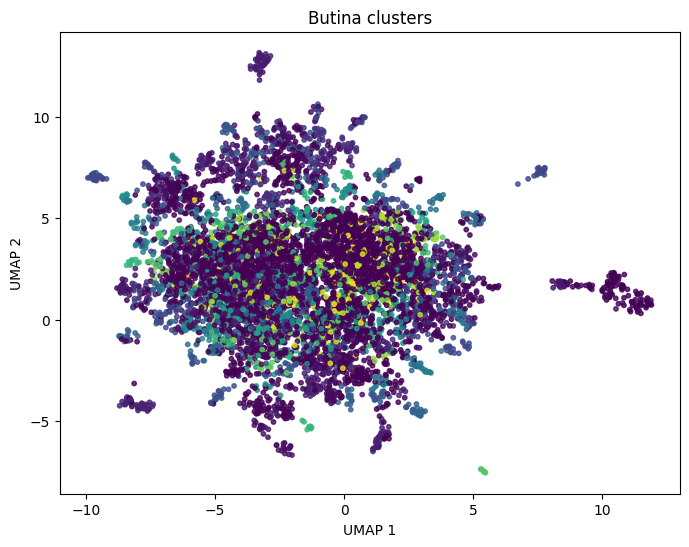

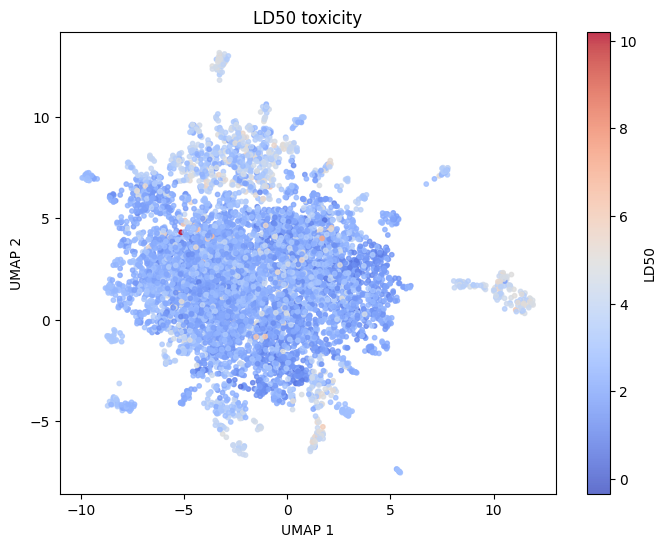

In [64]:
fig, ax1 = plt.subplots(figsize=(8,6))

# ax1 = Chemical space and butina clustering
ax1.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=butina_labels,
    cmap="viridis",
    s=10,
    alpha=0.8
)
ax1.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax1.set_title("Butina clusters")




fig, ax2 = plt.subplots(figsize=(8,6))



scatter2 = ax2.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=y,
    cmap="coolwarm",  # blue=low toxicity, red=high
    s=10,
    alpha=0.8,
    
)
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
ax2.set_title("LD50 toxicity")

cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label("LD50")

plt.show()



#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?

X_md: 0.620 => performed best
X_fg: 0.196 => performed weak, it doesn't capture physicochemical information
X_md_fg: 0.622 => small improvement to X_md 
X_md_scaf: 0.613 => scaffold decreased the performance with the describtors, introducing noise

=> descriptors add molecular properties that are more directly related to toxicity, whereas functional groups add minor hints, scaffold were too sparse to enhance the dataset


2) Is the One-Hot Encoding needed in this case?

In generel yes, it is necessary for categorical molecular features, but only when the number of categories is manageable. However here it added too many sparse columns, and also for functional groups it is useful, but the descriptors already contained most of the predictive information.

3) Did the feature filtering (variance, correlation) have an improving effect? Explain!

yes, slight improvement: Filtered score: 0.623
it removes features with almost no variance, removes redundant features, reduces overfitting, reduces complexity of models
here, random forests are already robust to redundant features, therefore it only had a slight imporvement effect; so in conclusion feature filtering can slightly improve performance, tho its not critical for tree-based models.

4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?

1. Load SMILES => compute descriptors, functional groups, scaffolds
2. One-hot encode categorical features
3. Concatenate features into a matrix
(4. filter features (variance, correlation))
5. Split data and train any model
6. Evaluate performance and compare feature sets

how to ensure compatibility:
- keep all features numeric arrays / pandas Dataframes
- use scikit-learn pipelines, so that the models have consistent features
- preprocessing ! to be able to adjust descriptors, scaffolds, functional groups etc. 

5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.

- Full-molecule fingerprints capture all substructures and functional groups => better for predicting toxicity and clustering.
- Scaffold fingerprints capture only the core skeleton => lose detail, clusters are coarser.

=> full-molecule fingerprints gives more meaningful clusters and visual separation in chemical space.

6) When might scaffolding prove useful?

- grouping molecules by core structure:
=> finding scaffold families
=> simplifying chemical space for visualization


7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?

- toxicity shows some correlation with chemical strucutre
- tho in general they seem to have the same toxicity level, kind of seems maybe to be an issue with how i chose the neihbours and the min distance, but it is hard to understand which settings are appropriate, in general i know that less neighbours will show local trends, whereas many neighbours will show global trends, the distance also changes how closely or far connected the clusters are